# Ski Conditions Baseline Model

Goal: train a first weather-only classifier for the folded ski-condition grades `A/B/C/D`.

This notebook follows the course-notes style: keep the data frame visible, turn things into `torch` tensors, define a small `nn.Module`, train with a simple loop, and inspect loss plus test-set metrics before getting fancy.


## setup

In [22]:
import random
from pathlib import Path

import pandas as pd
import torch
from torch import nn
from matplotlib import pyplot as plt

SEED = 42
PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data/processed/vt_condition_weather_aligned.csv"
TEST_SEASONS = 4
N_EPOCHS = 500
LEARNING_RATE = 0.05

random.seed(SEED)
torch.manual_seed(SEED)


## Load the aligned data

`grade` is already folded so that the four original rain weeks count as `D`. We keep `original_grade` and `target_was_rain` around for checking, but they should not be model features.


In [23]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df[["season", "label_date", "grade", "original_grade", "target_was_rain"]].head()


(741, 74)


,season,label_date,grade,original_grade,target_was_rain
0,2024-25,2024-11-16,D,D,False
1,2024-25,2024-11-23,D,D,False
2,2024-25,2024-11-30,D,D,False
3,2024-25,2024-12-07,B,B,False
4,2024-25,2024-12-14,D,D,False


In [24]:
print("folded grade counts")
print(df["grade"].value_counts().sort_index())

print()
print("original grade counts")
print(df["original_grade"].value_counts().sort_index())


folded grade counts
grade
A    161
B    159
C    161
D    260
Name: count, dtype: int64

original grade counts
original_grade
A    161
B    159
C    161
D    256
R      4
Name: count, dtype: int64


## Choose features and split by season

Because this is time-ish data, we hold out the most recent seasons instead of randomly mixing weeks. That makes the test set a little more honest.


In [25]:
class_names = ["A", "B", "C", "D"]
class_to_ix = {name: i for i, name in enumerate(class_names)}

season_order = sorted(df["season_start_year"].unique())
test_years = season_order[-TEST_SEASONS:]
train_years = season_order[:-TEST_SEASONS]

train_df = df[df["season_start_year"].isin(train_years)].copy()
test_df = df[df["season_start_year"].isin(test_years)].copy()

feature_cols = [
    col for col in df.columns
    if (col.startswith("avg_") or col.startswith("best_"))
    and pd.api.types.is_numeric_dtype(df[col])
    and "weather_days_observed" not in col
    and "location_count" not in col
]

print(f"train seasons: {train_df['season'].min()} through {train_df['season'].max()} ({len(train_df)} rows)")
print(f"test seasons:  {test_df['season'].min()} through {test_df['season'].max()} ({len(test_df)} rows)")
print(f"features: {len(feature_cols)}")
feature_cols[:8]


train seasons: 1999-00 through 2020-21 (627 rows)
test seasons:  2021-22 through 2024-25 (114 rows)
features: 52


['avg_hours_above_freezing_sum_7d',
 'avg_hours_above_freezing_mean_7d',
 'avg_hours_above_freezing_max_7d',
 'avg_hours_above_freezing_label_day',
 'avg_temperature_mean_7d',
 'avg_temperature_min_7d',
 'avg_temperature_max_7d',
 'avg_temperature_label_day']

In [26]:
X_train_raw = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_test_raw = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)

y_train = torch.tensor(train_df["grade"].map(class_to_ix).values, dtype=torch.long)
y_test = torch.tensor(test_df["grade"].map(class_to_ix).values, dtype=torch.long)

# standardize using the training set only
x_mean = X_train_raw.mean(dim=0)
x_std = X_train_raw.std(dim=0)
x_std[x_std == 0] = 1

X_train = (X_train_raw - x_mean) / x_std
X_test = (X_test_raw - x_mean) / x_std

X_train.shape, y_train.shape, X_test.shape, y_test.shape


(torch.Size([627, 52]),
 torch.Size([627]),
 torch.Size([114, 52]),
 torch.Size([114]))

## Logistic regression


In [27]:
class LogisticRegression(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.output_layer = nn.Linear(n_features, n_classes)

    def forward(self, X):
        return self.output_layer(X)


def train_model(model, X, y, epochs=N_EPOCHS, learning_rate=LEARNING_RATE):
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    losses = []

    for epoch in range(epochs):
        opt.zero_grad()
        scores = model(X)
        loss = loss_fn(scores, y)
        losses.append(loss.item())
        loss.backward()
        opt.step()
        if epoch % 500 == 0:
            print(f"epoch {epoch}: loss={loss.item():.4f}")

    return losses


epoch 0: loss=1.4076


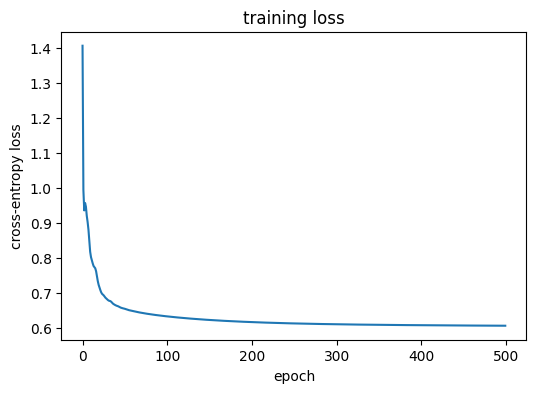

In [28]:
model = LogisticRegression(n_features=X_train.shape[1], n_classes=len(class_names))
losses = train_model(model, X_train, y_train)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(losses)
ax.set(xlabel="epoch", ylabel="cross-entropy loss", title="training loss")
plt.show()


## Evaluate

Accuracy, confusion matrix, and per-class precision/recall

In [29]:
def predict(model, X):
    with torch.no_grad():
        scores = model(X)
        probs = torch.softmax(scores, dim=1)
        preds = probs.argmax(dim=1)
    return preds, probs


def confusion_matrix(y_true, y_pred, n_classes):
    matrix = torch.zeros(n_classes, n_classes, dtype=torch.int64)
    for actual, pred in zip(y_true, y_pred):
        matrix[actual, pred] += 1
    return matrix


def metrics_table(matrix, class_names):
    rows = []
    for i, name in enumerate(class_names):
        tp = matrix[i, i].item()
        predicted = matrix[:, i].sum().item()
        actual = matrix[i, :].sum().item()
        precision = tp / predicted if predicted else 0.0
        recall = tp / actual if actual else 0.0
        rows.append({
            "class": name,
            "precision": precision,
            "recall": recall,
            "actual_count": actual,
            "predicted_count": predicted,
        })
    return pd.DataFrame(rows)


In [30]:
test_preds, test_probs = predict(model, X_test)
train_preds, train_probs = predict(model, X_train)

train_acc = (train_preds == y_train).float().mean().item()
test_acc = (test_preds == y_test).float().mean().item()

matrix = confusion_matrix(y_test, test_preds, len(class_names))
confusion = pd.DataFrame(matrix.numpy(), index=class_names, columns=class_names)

print(f"train accuracy: {train_acc:.3f}")
print(f"test accuracy:  {test_acc:.3f}")
confusion


train accuracy: 0.759
test accuracy:  0.588


,A,B,C,D
A,10,11,1,1
B,1,8,5,3
C,1,6,8,13
D,0,1,4,41


In [31]:
metrics_table(matrix, class_names)


,class,precision,recall,actual_count,predicted_count
0,A,0.833333,0.434783,23,12
1,B,0.307692,0.470588,17,26
2,C,0.444444,0.285714,28,18
3,D,0.706897,0.891304,46,58


## Simple NN


In [32]:
class MLP(nn.Module):
    def __init__(self, n_features, hidden_dim=128, n_classes=4):
        super().__init__()
        self.fc1 = nn.Linear(n_features, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.output_layer = nn.Linear(hidden_dim, n_classes)

    def forward(self, X):
        x = torch.relu(self.fc1(X))
        x = torch.relu(self.fc2(x))
        return self.output_layer(x)


mlp = MLP(n_features=X_train.shape[1], hidden_dim=512, n_classes=len(class_names))
mlp_losses = train_model(mlp, X_train, y_train, epochs=500, learning_rate=0.01)
mlp_preds, _ = predict(mlp, X_test)
(mlp_preds == y_test).float().mean().item()


epoch 0: loss=1.3725


0.6140350699424744

## Notes

Things to try next:

- compare avg-only features vs best-snow-only features vs combined features
- sweep the number of held-out seasons
- regularization
- inspect which classes are getting confused before adding model complexity
- switch from treating as multinomial classification to regression (some scale from D to A)
